File used for ad-hoc exploration of tracking.parquet

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_parquet("../data/tracking.parquet")
df.head()

,Image Id,Period,Game Clock,Player or Puck,Team,Player Id,Player Jersey Number,raw_x,raw_y,Rink Location Z (Feet),Goal Score,speed_mph_raw,speed_mph_savgol,gap_imputed,x,y,frame_id,accel_mph_s
0,2025-10-11 Team A @ Team D_065468,1,20:00,Player,Away,1,48,23.268,-12.181,1.0,NaN,NaN,0.327460,False,23.273685,-12.192322,65468.0,2.397997
1,2025-10-11 Team A @ Team D_065469,1,20:00,Player,Away,1,48,23.268,-12.181,1.0,NaN,0.000000,0.174859,False,23.275474,-12.175965,65469.0,2.549854
2,2025-10-11 Team A @ Team D_065470,1,20:00,Player,Away,1,48,23.284,-12.182,1.0,NaN,0.327911,0.151198,False,23.282039,-12.168021,65470.0,2.701711
3,2025-10-11 Team A @ Team D_065471,1,20:00,Player,Away,1,48,23.307,-12.184,1.0,NaN,0.472230,0.289974,False,23.293380,-12.168490,65471.0,2.853568
4,2025-10-11 Team A @ Team D_065472,1,20:00,Player,Away,1,48,23.334,-12.187,1.0,NaN,0.555671,0.462870,False,23.309498,-12.177371,65472.0,3.005425


In [5]:
df.describe()

,raw_x,raw_y,Rink Location Z (Feet),speed_mph_raw,speed_mph_savgol,x,y,frame_id,accel_mph_s
count,8.360755e+06,8.360755e+06,8.360752e+06,7.387715e+06,7.433415e+06,8.360755e+06,8.360755e+06,8.401602e+06,7.433239e+06
mean,-1.783656e+00,-1.267313e-01,9.060867e-01,9.774148e+00,9.001012e+00,-1.783648e+00,-1.267171e-01,1.713989e+05,1.420123e-01
std,6.229998e+01,2.162278e+01,5.117836e-01,5.578992e+00,5.155858e+00,6.229978e+01,2.162202e+01,8.858281e+04,1.214524e+01
min,-1.000000e+02,-4.248700e+01,-2.757050e+01,0.000000e+00,2.644843e-14,-1.004459e+02,-4.313027e+01,1.580000e+02,-6.388307e+02
25%,-6.170300e+01,-1.623500e+01,1.000000e+00,5.243109e+00,4.661513e+00,-6.170202e+01,-1.623310e+01,1.006190e+05,-5.411446e+00
50%,-4.143000e+00,-9.440000e-01,1.000000e+00,9.516308e+00,9.104561e+00,-4.144135e+00,-9.431049e-01,1.694680e+05,-5.146947e-02
75%,5.873700e+01,1.550700e+01,1.000000e+00,1.368078e+01,1.290975e+01,5.873969e+01,1.550731e+01,2.246390e+05,5.599297e+00
max,1.000000e+02,4.248700e+01,2.217100e+01,2.999929e+01,2.999381e+01,1.004810e+02,4.338099e+01,3.735760e+05,5.778899e+02


In [15]:

# NaN accel values — breakdown by cause
nan_accel = df[df['accel_mph_s'].isna()]
print(f"Total NaN accel rows: {len(nan_accel):,}")
print()

puck_nan = nan_accel[nan_accel['Player or Puck'] != 'Player']
player_nan = nan_accel[nan_accel['Player or Puck'] == 'Player']
print(f"  Puck rows (accel not computed for puck): {len(puck_nan):,}")
print(f"  Player rows with NaN accel:              {len(player_nan):,}")
print()

# Player NaN accel — these are segment boundaries / short segments (<5 frames)
total_player = (df['Player or Puck'] == 'Player').sum()
valid_accel  = df[(df['Player or Puck'] == 'Player') & df['accel_mph_s'].notna()].shape[0]
print(f"  Player rows total:       {total_player:,}")
print(f"  Player rows valid accel: {valid_accel:,}  ({100*valid_accel/total_player:.1f}% coverage)")


Total NaN accel rows: 968,363

  Puck rows (accel not computed for puck): 959,754
  Player rows with NaN accel:              8,609

  Player rows total:       7,441,848
  Player rows valid accel: 7,433,239  (99.9% coverage)


In [9]:
duplicates = df.groupby(['Player Id', 'Game Clock']).size()
duplicates_gt_1 = (duplicates > 1).sum()

print(f"Total unique (Player Id, Game Clock) pairs: {len(duplicates)}")
print(f"Pairs with more than one row: {duplicates_gt_1}")
print(f"\nAny duplicates? {duplicates_gt_1 > 0}")

if duplicates_gt_1 > 0:
    print(f"\nExample duplicates:")
    print(duplicates[duplicates > 1].head(10))

Total unique (Player Id, Game Clock) pairs: 269999
Pairs with more than one row: 263752

Any duplicates? True

Example duplicates:
Player Id  Game Clock
1          19:41         18
           19:42         30
           19:43         29
           19:44         31
           19:45         30
           19:46         30
           19:47         30
           19:48         30
           19:49         30
           19:50         30
dtype: int64


In [10]:
sample = df[(df['Player Id'] == '1') & (df['Game Clock'] == '19:44')].head(5)
print(sample[['Image Id', 'Player Id', 'Game Clock', 'Team', 'Rink Location X (Feet)', 'Rink Location Y (Feet)']])

                               Image Id Player Id Game Clock  Team  \
5494  2025-10-11 Team A @ Team D_065946         1      19:44  Away   
5506  2025-10-11 Team A @ Team D_065947         1      19:44  Away   
5518  2025-10-11 Team A @ Team D_065948         1      19:44  Away   
5530  2025-10-11 Team A @ Team D_065949         1      19:44  Away   
5542  2025-10-11 Team A @ Team D_065950         1      19:44  Away   

      Rink Location X (Feet)  Rink Location Y (Feet)  
5494                  81.113                   2.650  
5506                  81.100                   2.645  
5518                  81.113                   2.627  
5530                  81.321                   2.788  
5542                  81.413                   2.860  


In [11]:
df['Image Id'].unique()

<ArrowStringArray>
['2025-10-11 Team A @ Team D_065468', '2025-10-11 Team A @ Team D_065469',
 '2025-10-11 Team A @ Team D_065470', '2025-10-11 Team A @ Team D_065471',
 '2025-10-11 Team A @ Team D_065472', '2025-10-11 Team A @ Team D_065473',
 '2025-10-11 Team A @ Team D_065474', '2025-10-11 Team A @ Team D_065475',
 '2025-10-11 Team A @ Team D_065476', '2025-10-11 Team A @ Team D_065477',
 ...
 '2025-11-28 Team J @ Team K_343561', '2025-11-28 Team J @ Team K_343562',
 '2025-11-28 Team J @ Team K_343563', '2025-11-28 Team J @ Team K_343564',
 '2025-11-28 Team J @ Team K_343565', '2025-11-28 Team J @ Team K_343566',
 '2025-11-28 Team J @ Team K_343567', '2025-11-28 Team J @ Team K_343568',
 '2025-11-28 Team J @ Team K_343569', '2025-11-28 Team J @ Team K_343570']
Length: 959754, dtype: str

In [12]:
image_counts = df.groupby(['Period', 'Player Id'])['Image Id'].nunique().reset_index()
image_counts.columns = ['Period', 'Player Id', 'Image Count']

print("Image IDs per Period per Player:")
print(image_counts.groupby('Period')['Image Count'].describe())
print("\n")
print(image_counts.sort_values('Image Count', ascending=False).head(10))

Image IDs per Period per Player:
         count        mean         std  min    25%    50%     75%     max
Period                                                                   
1       4656.0  586.357603  528.513860  1.0  182.0  435.5  825.25  3533.0
2       5499.0  471.710857  449.003737  1.0  142.0  333.0  671.50  5276.0
3       5173.0  389.885753  379.688721  1.0  123.0  271.0  530.00  4499.0
OT       353.0  285.977337  295.460926  1.0   90.0  204.0  381.00  2385.0


      Period Player Id  Image Count
8533       2      6597         5276
14396      3      8862         4499
57         1      1051         3533
9001       2      7210         3408
3127       1       332         3394
4111       1       642         3304
1594       1      1858         3259
3138       1      3332         3256
1242       1      1533         3249
3990       1       533         3174


In [16]:
df_images = df.drop_duplicates(subset=['Image Id'], keep='first')

images_per_clock = df_images.groupby(['Period', 'Game Clock']).size().reset_index(name='Image Count')

print("Images per Game Clock second (by Period):")
print(images_per_clock.groupby('Period')['Image Count'].describe())
print("\n")
print("Total seconds per period:")
print(images_per_clock.groupby('Period').size())

Images per Game Clock second (by Period):
         count        mean        std    min    25%    50%    75%    max
Period                                                                  
1       1201.0  287.018318  22.681630  152.0  272.0  294.0  302.0  355.0
2       1201.0  281.015820  26.359955  174.0  267.0  284.0  301.0  370.0
3       1201.0  214.655287  32.006917  118.0  200.0  210.0  221.0  475.0
OT       301.0   61.933555  16.636173    1.0   56.0   61.0   63.0  115.0


Total seconds per period:
Period
1     1201
2     1201
3     1201
OT     301
dtype: int64


In [14]:
from datetime import datetime, timedelta

def parse_clock(clock_str):
    if pd.isna(clock_str):
        return None
    parts = str(clock_str).split(':')
    return int(parts[0]) * 60 + int(parts[1])

images_per_clock['Clock_Seconds'] = images_per_clock['Game Clock'].apply(parse_clock)

for period in ['1', '2', '3', 'OT']:
    period_data = images_per_clock[images_per_clock['Period'] == period].sort_values('Clock_Seconds')
    
    if len(period_data) > 0:
        min_clock = period_data['Clock_Seconds'].min()
        max_clock = period_data['Clock_Seconds'].max()
        actual_count = len(period_data)
        expected_count = max_clock - min_clock + 1 if min_clock is not None else 0
        
        print(f"Period {period}: {actual_count} seconds vs {expected_count} expected ({min_clock}s to {max_clock}s)")
        if actual_count < expected_count:
            all_seconds = set(range(min_clock, max_clock + 1))
            actual_seconds = set(period_data['Clock_Seconds'].values)
            missing = sorted(all_seconds - actual_seconds)
            print(f"  Missing {len(missing)} seconds: {missing[:20]}")  # Show first 20

Period 1: 1201 seconds vs 1201 expected (0s to 1200s)
Period 2: 1201 seconds vs 1201 expected (0s to 1200s)
Period 3: 1201 seconds vs 1201 expected (0s to 1200s)
Period OT: 301 seconds vs 301 expected (0s to 300s)


In [25]:
df['Game'] = df['Image Id'].str.extract(r'(^\d{4}-\d{2}-\d{2}.*?)_')[0]

print("Image count consistency per Game per Period per Clock (one entry per image):")
game_period_clock_counts = df_images.groupby(['Game', 'Period', 'Game Clock']).size().reset_index(name='Image Count')

consistency = game_period_clock_counts.groupby(['Game', 'Period'])['Image Count'].agg(['min', 'max', 'mean'])
print(consistency[consistency['min'] != consistency['max']])  # Show games with inconsistent counts

if len(consistency[consistency['min'] != consistency['max']]) == 0:
    print("All games have consistent image counts per second within each period!")
else:
    print(f"\n{len(consistency[consistency['min'] != consistency['max']])} game-periods have inconsistent image counts")

Image count consistency per Game per Period per Clock (one entry per image):
                                   min  max       mean
Game                       Period                     
2025-10-11 Team A @ Team D 1         1   57  29.846487
                           2         1   59  29.945346
                           3         1   59  29.995759
2025-10-17 Team F @ Team L 1         1   60  30.063158
                           2         1   62  29.803265
                           3         1   62  29.833181
2025-10-24 Team B @ Team A 1         1   58  29.794143
                           2         1   55  29.834619
                           3         1   59  29.895993
2025-10-24 Team E @ Team D 1         1   61  29.943096
                           2         1   62  29.991131
                           3         3   55  30.217593
                           OT        2   58  30.063830
2025-10-28 Team C @ Team A 1         1   57  29.716146
                           2         1   62

In [18]:
per_game_images = df_images.groupby(['Game', 'Period', 'Game Clock']).size().reset_index(name='Image Count')

print("Images per Game Clock per Game per Period:")
print(per_game_images.groupby(['Game', 'Period'])['Image Count'].describe())
print("\n")
print("Sample of one game, one period:")
sample_game = per_game_images[(per_game_images['Game'] == per_game_images['Game'].iloc[0]) & 
                               (per_game_images['Period'] == '1')]
print(sample_game.head(20))

Images per Game Clock per Game per Period:
                                    count       mean        std   min   25%  \
Game                       Period                                             
2025-10-11 Team A @ Team D 1       1153.0  29.846487   3.767532   1.0  30.0   
                           2       1171.0  29.945346   3.777407   1.0  30.0   
                           3       1179.0  29.995759   3.348336   1.0  30.0   
2025-10-17 Team F @ Team L 1       1140.0  30.063158   3.896539   1.0  30.0   
                           2       1164.0  29.803265   6.437740   1.0  29.0   
                           3       1091.0  29.833181   5.173649   1.0  30.0   
2025-10-24 Team B @ Team A 1       1161.0  29.794143   4.553494   1.0  30.0   
                           2       1167.0  29.834619   4.178180   1.0  30.0   
                           3       1173.0  29.895993   5.477328   1.0  29.0   
2025-10-24 Team E @ Team D 1       1195.0  29.943096   5.403341   1.0  30.0   
         

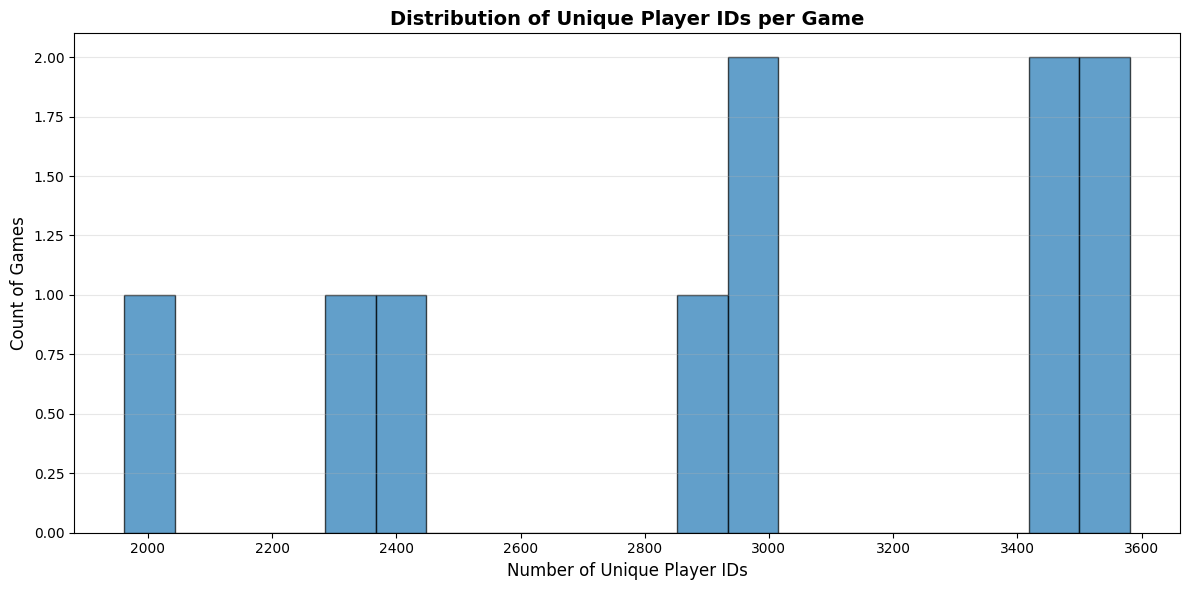

Unique Player IDs per game:
count      10.000000
mean     2953.400000
std       581.324197
min      1962.000000
25%      2492.500000
50%      2986.000000
75%      3461.000000
max      3581.000000
Name: Player Id, dtype: float64


In [21]:
players_per_game = df.groupby('Game')['Player Id'].nunique()

plt.figure(figsize=(12, 6))
plt.hist(players_per_game, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Unique Player IDs', fontsize=12)
plt.ylabel('Count of Games', fontsize=12)
plt.title('Distribution of Unique Player IDs per Game', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Unique Player IDs per game:")
print(players_per_game.describe())

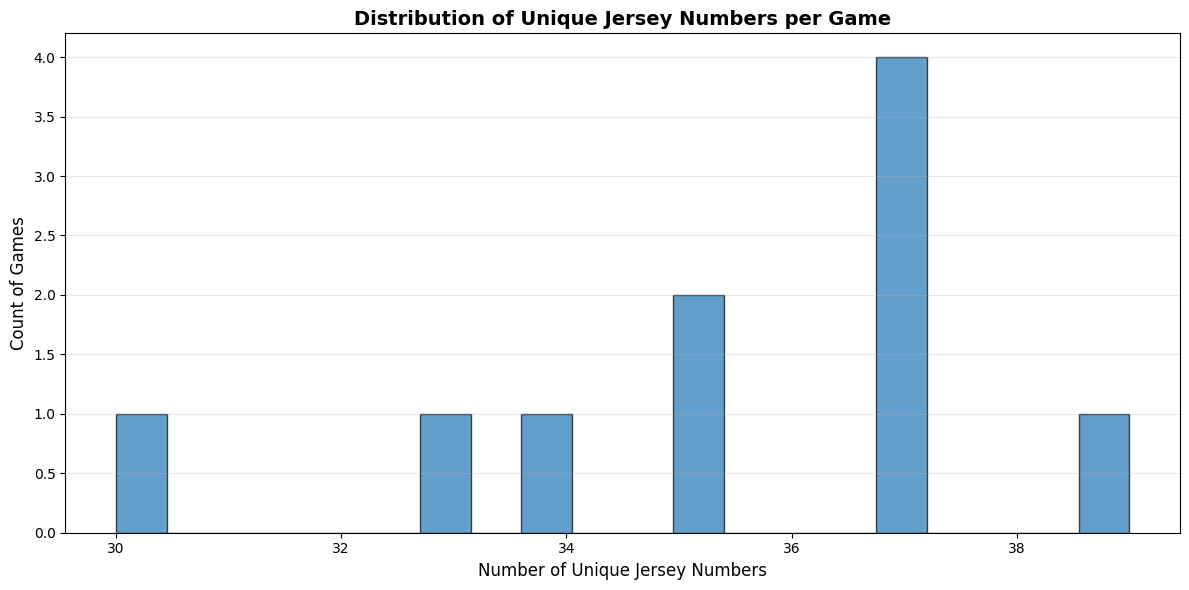

Unique Jersey Numbers per game:
count    10.000000
mean     35.400000
std       2.590581
min      30.000000
25%      34.250000
50%      36.000000
75%      37.000000
max      39.000000
Name: Player Jersey Number, dtype: float64


In [26]:
jerseys_per_game = df.groupby('Game')['Player Jersey Number'].nunique()

plt.figure(figsize=(12, 6))
plt.hist(jerseys_per_game, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Unique Jersey Numbers', fontsize=12)
plt.ylabel('Count of Games', fontsize=12)
plt.title('Distribution of Unique Jersey Numbers per Game', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Unique Jersey Numbers per game:")
print(jerseys_per_game.describe())